### __Consigna__
Realizar un EDA básico del dataset seleccionado:
* estadística descriptiva
* tipos de variables
* identificación de duplicados, nulos, outliers
* incluir al menos 3 gráficos

### **Resolución**
Set de datos elegido: [Gaming and Mental Health](https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health)

In [1]:
# Lo  primero que tengo que hacer es importar todas las bilbiotecas que voy a necesitar:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Tomo la base de datos y formo el dataframe utilizando Pandas
vg_addiction_df = pd.read_csv('./Gaming_and_Mental_Health.csv', sep=';')

# Imprimo las primeras filas del dataframe para verificar su contenido
vg_addiction_df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


A continuación voy a listar cuales son las columnas que tenemos dentro del dataframe, también voy a aclarar que tipo de variable es:
* Identificador de la columna (No es muy útil, salvo para enumerar cada columna)
* Edad de la persona (**Numérica**)
* Género de la persona (**Categórica**)
* Cantidad de horas de juego diaria (**Numérica**)
* Género de juego preferido (**Categórica**)
* Juego al que habitualmente juegan (**Categórica**)
* Plataforma (**Categórica**)
* Horas de sueño (**Numérica**)
* Calidad de sueño (**Categórica**)
* Con que frecuencia se interrumpe su sueño (**Categórica**)
* Desempeño en sus estudios/trabajo
* Promedio escolar (**Numérica**)
* Productividad en el trabajo (**Numérica**)
* Humor
* Con que frecuencia suelen cambiar de humor
* Síntomas de abstinencia 
* Perdida de interes por el resto de las cosas
* Si siguió jugando a pesar del malestar (**Categórica/Binaria**)
* Cansancion ocular (**Categórica/Binaria**)
* Dolor de espalda (Categórica/Binaria)
* Diferencia de peso desde que juegan (**Numérica**)
* Horas de ejercicio semanales (**Numérica**)
* Que tan pocos sociales creen ser (**Catagórica, en escala del 1 al 10**)
* Cuanto tiempo interactuan con la gente cara a cara durante la semana (**Numérica**)
* Dinero gastado mensualmente en juego (**Numérica**)
* Años jugando (**Numérica**)
* Riesgo de adicción al juego (**Categórica**)

#### _Estadística Descriptiva_

Voy a empezar con las variables numéricas. La idea es obtener la Media, Mediana, Varianza, desvio estandar, entre otros
Lo primero que debería hacer, es saber cuales de todas ellas son datos numéricos y separarlos para poder utilzar las herramientas de Panda

In [3]:

# Voy a quedarme solo con los datos numéricos
df = vg_addiction_df.select_dtypes(include='number')

# Obtengo las estadísticas de los datos

mean_df = df.mean() # Media de los datos numéricos
median_df = df.median() # Mediana de los datos numéricos
mode_df = df.mode() # Moda de los datos numéricos
std_df = df.std(ddof=0) # Desvio Estandar de los datos numéricos
var_df = df.var(ddof=0) # Varianza de los datos numéricos
iqr_df = df.quantile(0.75) - df.quantile(0.25) # Rango intercuartil

# Todos estos datos voy a ubicarlos en una tabla para mejorar la visualización.
# Primero voy a crear un diccionario para luego pasarlo a dataframe

stats= {
    'Dato': ['Edad', 'Tiempo de juego Diario', 'Horas de Sueño', 'Promedio Escolar', 
             'Productividad', 'Cambio en el peso', 'Horas de ejercicio semanal', 
             'Aislamiento social', 'Contacto con otras personas', 
             'Dinero gastado al mes', 'Años jugando'],
    'Media': mean_df.values[:],
    'Mediana': median_df.values,
    'Moda': mode_df.iloc[0].values,
    'Desvio Estandar': std_df.values,
    'Varianza': var_df.values,
    'IQR': iqr_df.values
}

# Creo el dataframe en base a mi diccionario

stats_df = pd.DataFrame(stats)

# Imprimo los resultados
stats_df


,Dato,Media,Mediana,Moda,Desvio Estandar,Varianza,IQR
0,Edad,20.475000,20.000,19.00,4.114046,16.925375,4.000
1,Tiempo de juego Diario,6.151400,6.000,5.80,2.865760,8.212578,3.925
2,Horas de Sueño,5.738100,5.700,5.30,1.440492,2.075018,1.800
3,Promedio Escolar,2.518037,2.530,1.40,0.871733,0.759919,1.520
4,Productividad,5.394659,5.000,9.00,2.896591,8.390239,5.000
5,Cambio en el peso,1.513400,1.100,0.10,1.431496,2.049180,1.700
6,Horas de ejercicio semanal,6.945900,7.000,6.40,1.804124,3.254863,2.500
7,Aislamiento social,3.872000,4.000,3.00,2.090363,4.369616,3.000
8,Contacto con otras personas,7.654500,8.000,0.00,3.750077,14.063080,5.400
9,Dinero gastado al mes,105.219730,66.405,67.44,113.829810,12957.225711,93.650


#### _Valores Faltantes_

Voy a buscar si en la tabla tengo algún faltante y contabilizarlos:

In [4]:
# Busco si tengo algún faltante y hago el recuento de los datos:
print(vg_addiction_df.isnull().sum()[vg_addiction_df.isnull().sum() > 0])

grades_gpa                 246
work_productivity_score    326
dtype: int64


**Interpretación Preliminar:** 
 - Vemos que tenemos un total de 246 faltantes en las calificaciones escolares, que puede estar relacionado a una falta de escolarización o quizas no haber terminado los estudios. También puede deberse a bajas calificaciones y la necesidad de querer "Ocultar" sus notas.
 - Por otro lado, también tenemos un faltante de 326 datos en la productividad laboral. Esto puede deberse a gente que o no tiene trabajo porque puede estar dedicandose a sus estudios o quizas no cumpla con la edad mínima para ello.

### _Visualización de datos categóricos_

In [5]:
# Voy a agrupar todas las variables categóricas para usarlas como entradas dentro
# de un for y luego imprimir los subgrupos dentro de cada una de ellas.
cat_cols = ['gaming_addiction_risk_level', 'gender', 'game_genre',
            'gaming_platform','sleep_quality', 'sleep_disruption_frequency',
            'mood_state', 'academic_work_performance', 'mood_swing_frequency', 'primary_game']

# Agrupo todas las variables categóricas
for col in cat_cols:
    print(f"\n")
    print(vg_addiction_df[col].value_counts())



gaming_addiction_risk_level
Low         514
Moderate    190
High        154
Severe      142
Name: count, dtype: int64


gender
Male      647
Female    331
Other      22
Name: count, dtype: int64


game_genre
MOBA             156
RPG              146
MMO              143
Battle Royale    141
Strategy         141
Mobile Games     139
FPS              134
Name: count, dtype: int64


gaming_platform
Mobile            262
Multi-platform    260
PC                241
Console           237
Name: count, dtype: int64


sleep_quality
Fair         293
Poor         283
Good         212
Very Poor    175
Insomnia      37
Name: count, dtype: int64


sleep_disruption_frequency
Often        221
Sometimes    205
Never        200
Rarely       193
Always       181
Name: count, dtype: int64


mood_state
Normal       172
Anxious      169
Irritable    147
Restless     135
Euphoric     107
Angry        102
Depressed     88
Withdrawn     40
Excited       40
Name: count, dtype: int64


academic_work_performanc

Voy a tomar algunos de estos datos y pasarlos a gráficos para que la información sea un poco mas legible.

#### Graficos de Barras

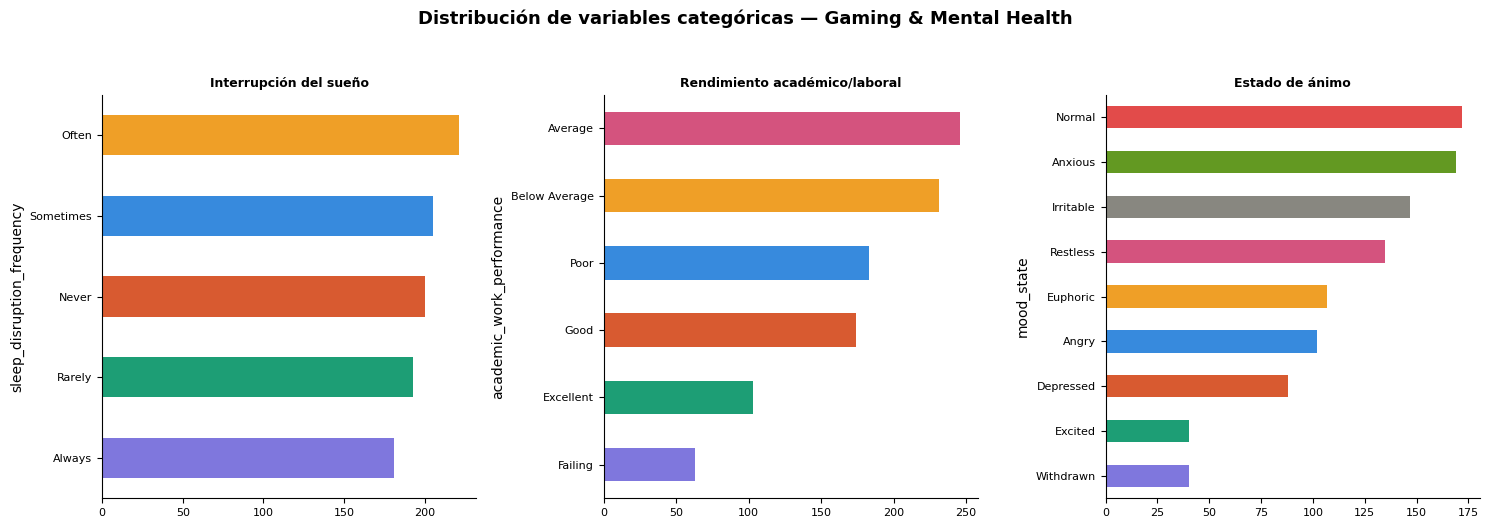

In [6]:
# Defino la paleta de colores que quiero para mi gráfico
PALETTE = ['#7F77DD','#1D9E75','#D85A30','#378ADD','#EF9F27',
           '#D4537E','#888780','#639922','#E24B4A','#A32D2D']

# Voy a definir dentro de un diccionario todas las variables categóricas
cat_cols = {
    'Interrupción del sueño':        'sleep_disruption_frequency',
    'Rendimiento académico/laboral': 'academic_work_performance',
    'Estado de ánimo':               'mood_state',
}

# Genero la grilla que deseo para mostrar los gráficos
fig, axes = plt.subplots(4, 3, figsize=(15, 18))  # 3 columnas
axes = axes.flatten()

# Imprimo los gráficos de acuerdo a los datos obtenidos 
# anteriormente.
for ax, (title, col) in zip(axes, cat_cols.items()):
    # Tomo los datos
    counts = vg_addiction_df[col].value_counts()
    # Los ordeno de menor a mayor
    counts = counts.sort_values()
    # Defino el color que van a tener dentro del gráfico
    bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(counts))]
    counts.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='none')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines[['top','right']].set_visible(False)

# Ocultar el subplot sobrante (el 11vo y 12vo si hay)
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

# Le pongo un nombre al gráfico y lo muestro
plt.suptitle('Distribución de variables categóricas — Gaming & Mental Health',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Graficos de Torta

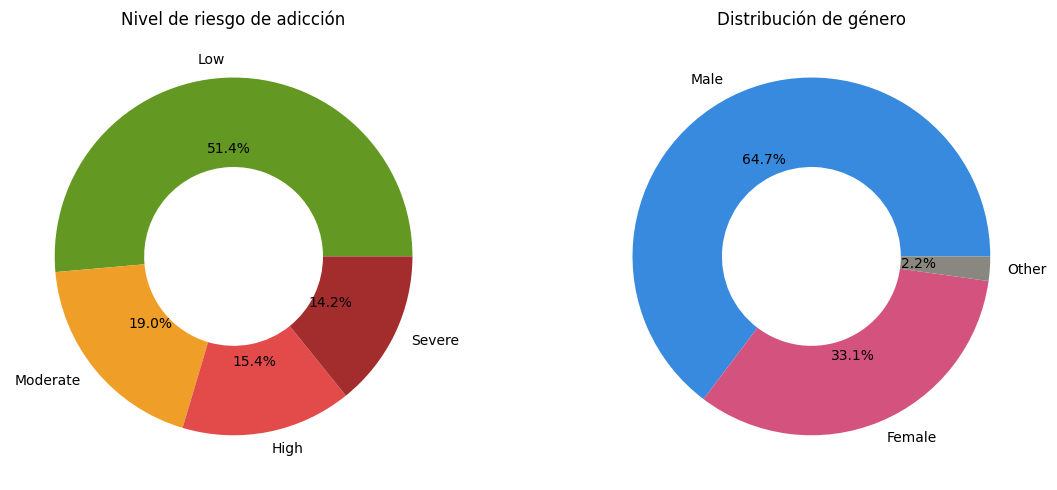

In [7]:
# Genero la grilla para la visulación de los datos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Lo primero que tengo que hacer es obtener cuales son los datos que deseo mostrar
# Voy a tomar el dato de "Riesgo de adicción"
risk_counts = vg_addiction_df['gaming_addiction_risk_level'].value_counts()
# Armo el gráfico con la variable que obtuvo en la linea anterior
axes[0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['#639922','#EF9F27','#E24B4A','#A32D2D'],
            wedgeprops={'width': 0.5})
# Le pongo el título al gráfico
axes[0].set_title('Nivel de riesgo de adicción')

# Ahora voy a tomar el dato del génro
gender_counts = vg_addiction_df['gender'].value_counts()
# Armo el gráfico con la variable que obtuvo en la linea anterior
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#378ADD','#D4537E','#888780'],
            wedgeprops={'width': 0.5})
# Le pongo el título al gráfico
axes[1].set_title('Distribución de género')

# Muestro los resultados
plt.tight_layout()
plt.show()

#### _Gráficos Combinados_

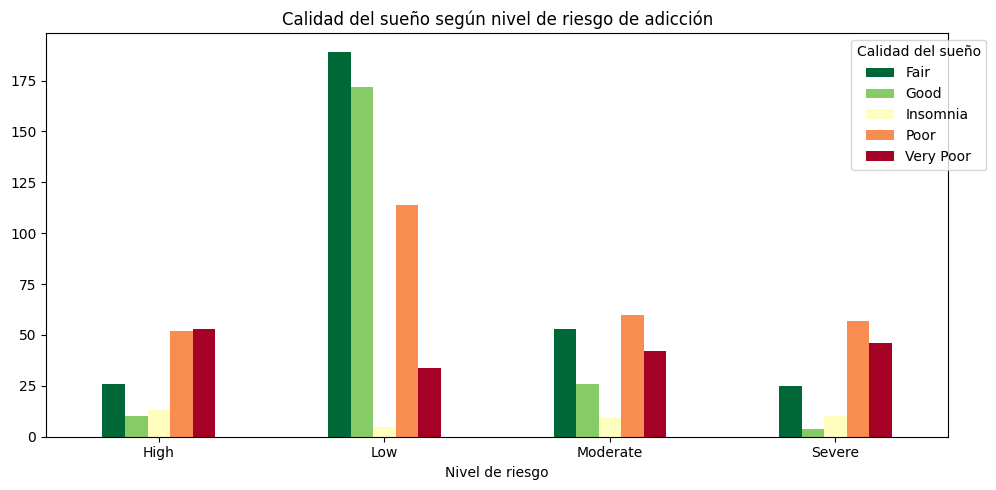

In [8]:
# Tomo el dato de la calidad de sueño y formo un gráfico de barras en función del nivel de adicción
pd.crosstab(vg_addiction_df['gaming_addiction_risk_level'], vg_addiction_df['sleep_quality']).plot(
    kind='bar', figsize=(10, 5), colormap='RdYlGn_r', edgecolor='none')

# Le agrego el título y los labels de ambos ejes
plt.title('Calidad del sueño según nivel de riesgo de adicción')
plt.xlabel('Nivel de riesgo')
plt.xticks(rotation=0)
plt.legend(title='Calidad del sueño', bbox_to_anchor=(1.05, 1))

# Muestro los resultados
plt.tight_layout()
plt.show()

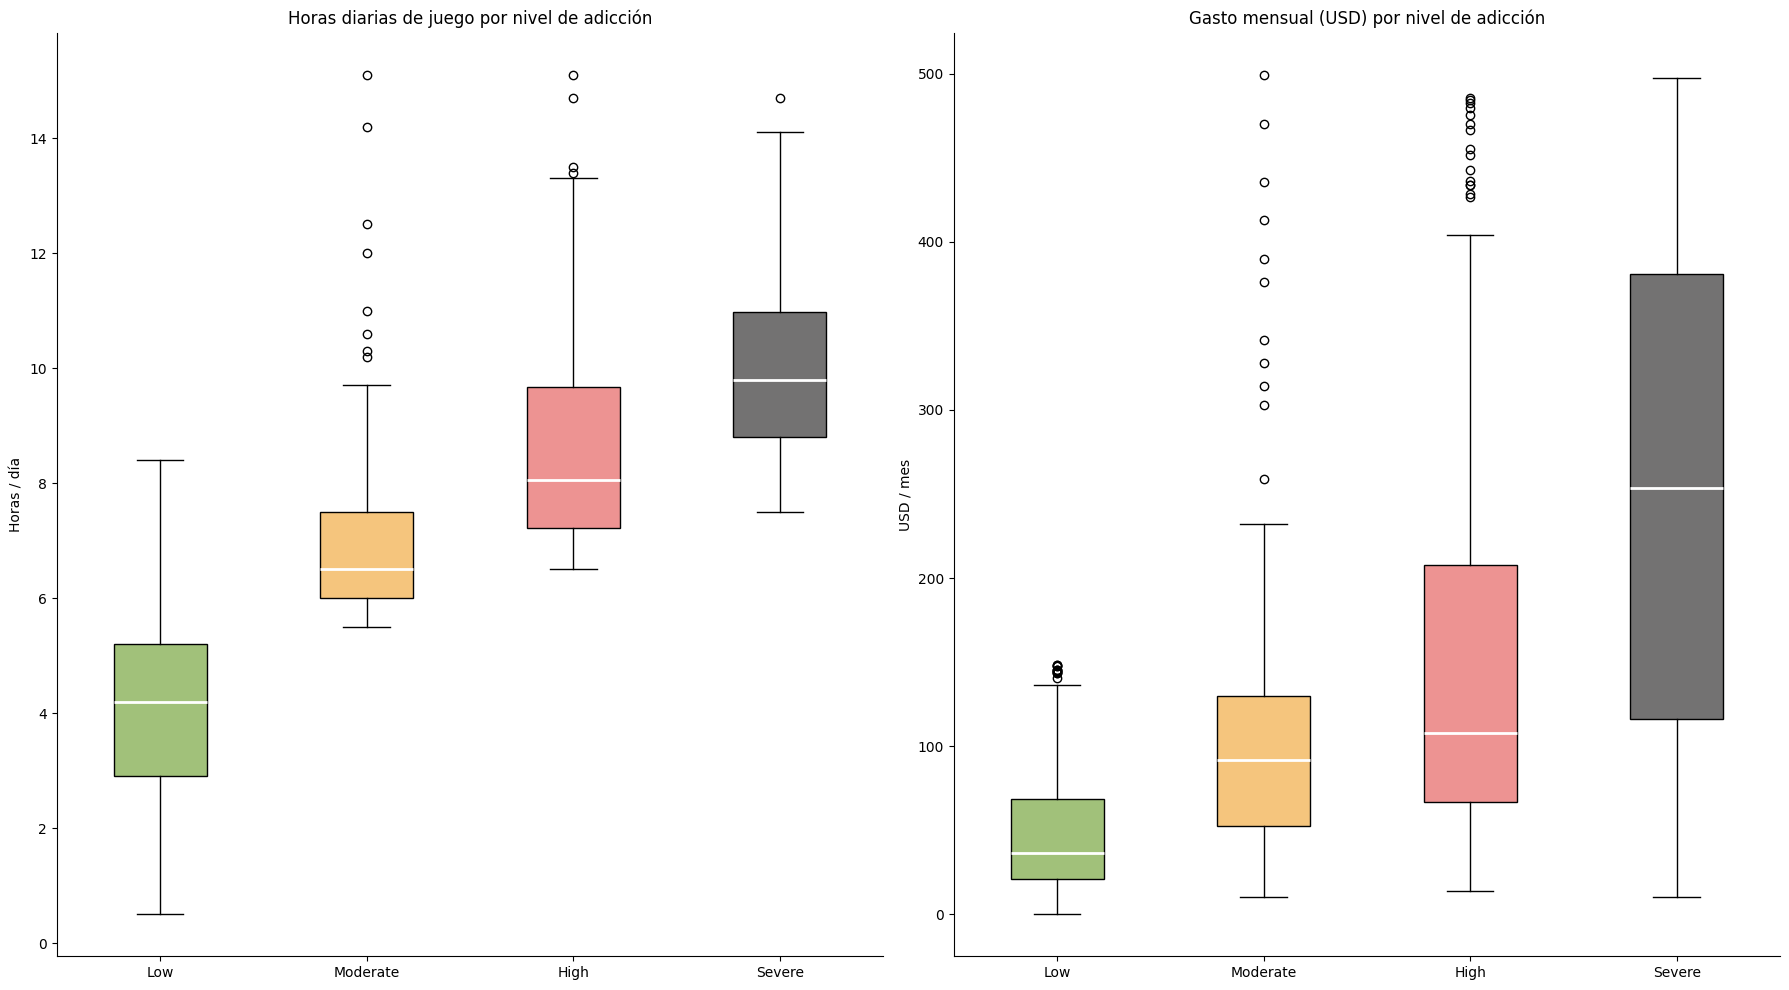

In [9]:
# Determino cuales son mis 4 categorías a incluir en el eje X
order = ['Low', 'Moderate', 'High', 'Severe']
# Los colores me van a indicar el nivel de riesgo
colors = ['#639922', '#EF9F27', '#E24B4A', "#161515"]
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Agrupo las distintas entradas de horas de juego de acuerdo al nivel de adicción que se tiene, es decir, 
# voy a conformar 4 tablas con las distintas entradas de horas de juegos, una por cada nivel de adicción
data_hours = [vg_addiction_df[vg_addiction_df['gaming_addiction_risk_level']==lvl]['daily_gaming_hours'] for lvl in order]
# Creo el boxplot de acuerdo a los datos obtenidos anteriormente
bp1 = axes[0].boxplot(data_hours, patch_artist=True, medianprops=dict(color='white', linewidth=2))
# Fijo los colores de cada uno de las cajas de los boxplots
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color + '99')
# Agrego los labels X/Y del gráfico, como también su título
axes[0].set_xticklabels(order)
axes[0].set_title('Horas diarias de juego por nivel de adicción')
axes[0].set_ylabel('Horas / día')
axes[0].spines[['top','right']].set_visible(False)

# Agrupo las distintas entradas de gasto mensual de acuerdo al nivel de adicción que se tiene, es decir, 
# voy a conformar 4 tablas con las distintas entradas de horas de juegos, una por cada nivel de adicción
data_spend = [vg_addiction_df[vg_addiction_df['gaming_addiction_risk_level']==lvl]['monthly_game_spending_usd'] for lvl in order]
# Creo el boxplot de acuerdo a los datos obtenidos anteriormente
bp2 = axes[1].boxplot(data_spend, patch_artist=True, medianprops=dict(color='white', linewidth=2))
# Fijo los colores de cada uno de las cajas de los boxplots
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color + '99')
# Agrego los labels X/Y del gráfico, como también su título
axes[1].set_xticklabels(order)
axes[1].set_title('Gasto mensual (USD) por nivel de adicción')
axes[1].set_ylabel('USD / mes')
axes[1].spines[['top','right']].set_visible(False)

# Muestro los resusltados
plt.tight_layout()
plt.show()

### **Conclusiones**

**NOTA:** Está claro que pueden hacerse muchas otras comparaciones entre variables, lo cual generaría un número mayor de conclusiones, en este trabajo se presentan algunas a modo informativo

Algunas conclusiones que obtuve del análisis:
* **El sueño es la variable más preocupante:** La media de horas de sueño es de 5.738100, muy por debajo de las 8 recomendadas. Y en la variable de calidad del sueño, las categorías Poor y Very Poor superan juntas a Good. Una porción grande de la muestra duerme poco, mal y con interrupciones frecuentes.
* **Rendimiento académico sesgado hacia lo negativo:**  Las categorías Average, Below Average y Poor concentran el 66% de los casos, mientras que Excellent apenas alcanza el 10.3%. Esto es relevante porque grades_gpa tiene un 24.6% de valores faltantes, es posible que muchos de esos datos faltantes correspondan justamente a los peores casos, lo que podría estar suavizando el panorama real (Cosa que mencioné anteriormente al analizar los datos faltantes)
* **Horas de juego:** La separación entre grupos es casi perfecta, la mediana pasa de 4.2 hs (Low) a 9.8 hs (Severe) con muy poco solapamiento entre cajas.
* **Gasto mensual:** La diferencia es dramática. La mediana del grupo Severe ($253) es casi 7 veces la del grupo Low ($36). Además, la dispersión crece mucho en los grupos de mayor riesgo, lo que sugiere que hay un subgrupo de jugadores que gasta sumas muy altas.